<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/tools_numpy.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso:  ]()



Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/intro_ml_dl/blob/main/5_images/taller_estructuras_datos_python_2025-09-04%20a%20las%2020.38.jpg?raw=true'>  



In [ ]:
import pandas as pd
from datetime import datetime

# Ruta del archivo principal
path = 'C:/Users/marco/Documentos/docencia/groups_list/g_lideres.xlsx'

def registrar_asistencia():
    """Registrar asistencia de estudiantes G-líderes en el mismo archivo g_lideres.xlsx"""
    
    # Leer todas las hojas existentes
    try:
        xls = pd.ExcelFile(path)
        df_estudiantes = pd.read_excel(xls, sheet_name="Estudiantes")
        df_asistencia = pd.read_excel(xls, sheet_name="Asistencia")
    except ValueError:
        # Si no existen hojas, inicializarlas
        df_estudiantes = pd.DataFrame(columns=["Nombre", "Programa"])
        df_asistencia = pd.DataFrame(columns=["Nombre", "Programa", "Taller", "Fecha"])
    
    print("=== Registro de Asistencia - G-Líderes ===")
    
    while True:
        nombre = input("\nIngrese el nombre completo del estudiante (ENTER para terminar): ").strip()
        if nombre == "":
            break
        
        # Verificar si el estudiante ya existe
        if nombre in df_estudiantes["Nombre"].values:
            programa = df_estudiantes.loc[df_estudiantes["Nombre"] == nombre, "Programa"].values[0]
            print(f"{nombre} encontrado en la lista ({programa}).")
        else:
            programa = input(f"{nombre} no está registrado. Ingrese el programa académico: ")
            nuevo_estudiante = pd.DataFrame([[nombre, programa]], columns=["Nombre", "Programa"])
            df_estudiantes = pd.concat([df_estudiantes, nuevo_estudiante], ignore_index=True)
            print(f"{nombre} agregado a la lista de estudiantes.")
        
        # Registrar asistencia
        taller = input("Ingrese el nombre del taller: ")
        fecha = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        nuevo_registro = pd.DataFrame([[nombre, programa, taller, fecha]], 
                                      columns=["Nombre", "Programa", "Taller", "Fecha"])
        df_asistencia = pd.concat([df_asistencia, nuevo_registro], ignore_index=True)
        print(f"Asistencia registrada para {nombre} en el taller '{taller}'.")
    
    # Guardar de nuevo en el mismo archivo
    with pd.ExcelWriter(path, engine="openpyxl", mode="w") as writer:
        df_estudiantes.to_excel(writer, sheet_name="Estudiantes", index=False)
        df_asistencia.to_excel(writer, sheet_name="Asistencia", index=False)
    
    print(f"\n Registro actualizado en {path}")



In [9]:

# Ejemplo de uso
registrar_asistencia()


=== Registro de Asistencia - G-Líderes ===
✅ marco julio cañas campillo agregado a la lista de estudiantes.
📌 Asistencia registrada para marco julio cañas campillo en el taller 'clasificación con perceptrón'.
✅ marco julio cañas campillo encontrado en la lista (licenciatura en matemáticas).
📌 Asistencia registrada para marco julio cañas campillo en el taller 'clasificación con perceptrón'.

📂 Registro actualizado en C:/Users/marco/Documentos/docencia/groups_list/g_lideres.xlsx


In [10]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/g_lideres.xlsx'
df = pd.read_excel(path)

df.index = range(1, len(df) + 1)
df 

,Nombre,Programa
1,marco julio cañas campillo,licenciatura en matemáticas


# Clasificación con Perceptrón en administración de empresas 

Este es un **resumen didáctico en español** de las páginas 472–483 de *Hands-On Machine Learning (3ra ed.) de Aurélien Géron*.



# Resumen Didáctico: El Perceptrón y el Perceptrón Multicapa



## 1. El Perceptrón: idea inicial

* Fue propuesto en **1957 por Frank Rosenblatt**.
* Se basa en una **unidad lógica de umbral (TLU: Threshold Logic Unit)**.
* Cada conexión tiene un **peso** $w_{i}$.
* La TLU calcula una **combinación lineal** de las entradas:

$$
z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b
$$

* Luego aplica una **función escalón (step function)**:

$$
h(\mathbf{x}) = \text{step}(z)
$$



### Funciones escalón comunes:

* **Heaviside**:

$$
\text{heaviside}(z) = \begin{cases} 
0 & \text{si } z < 0 \\ 
1 & \text{si } z \geq 0 
\end{cases}
$$



* **Función signo**:

$$
\text{sgn}(z) = \begin{cases} 
-1 & \text{si } z < 0 \\ 
0 & \text{si } z = 0 \\ 
1 & \text{si } z > 0 
\end{cases}
$$

Esto lo hace muy similar a la **regresión logística**, pero con una función escalón en lugar de la logística.

---



## 2. Arquitectura del Perceptrón

* Un **perceptrón** es una capa de TLUs totalmente conectadas.
* La entrada es la **capa de entrada** y la salida es la **capa de salida**.

Ejemplo: un perceptrón con 2 entradas y 3 salidas puede clasificar en **tres clases binarias al mismo tiempo** (clasificador multietiqueta).



### Notación matricial:

Si $X$ es la matriz de entradas, $W$ los pesos y $b$ los sesgos:

$$
h_{W,b}(X) = \phi(XW + b)
$$

donde $\phi$ es la función de activación (aquí, escalón).

---



## 3. Entrenamiento del Perceptrón

* Se inspira en la **regla de Hebb**:
  *“Las neuronas que se activan juntas, se conectan más fuerte”*.

* Rosenblatt adaptó la idea: actualizar pesos **según el error cometido**.



### Regla de aprendizaje del perceptrón:

$$
w_{i,j} \leftarrow w_{i,j} + \eta (y_j - \hat{y}_j)x_i
$$

donde:

* $w_{i,j}$ = peso de la conexión entre la entrada $i$ y la neurona de salida $j$.
* $\eta$ = tasa de aprendizaje.
* $y_{j}$ = salida esperada.
* $\hat{y}_{j}$ = salida predicha.


# Nota importante  

Si los datos son **linealmente separables**, el algoritmo **converge** (Teorema de Convergencia del Perceptrón).





## 4. Implementación en Python con Scikit-Learn


In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron


In [9]:

# Dataset: Iris
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)  # Clasificar Iris Setosa


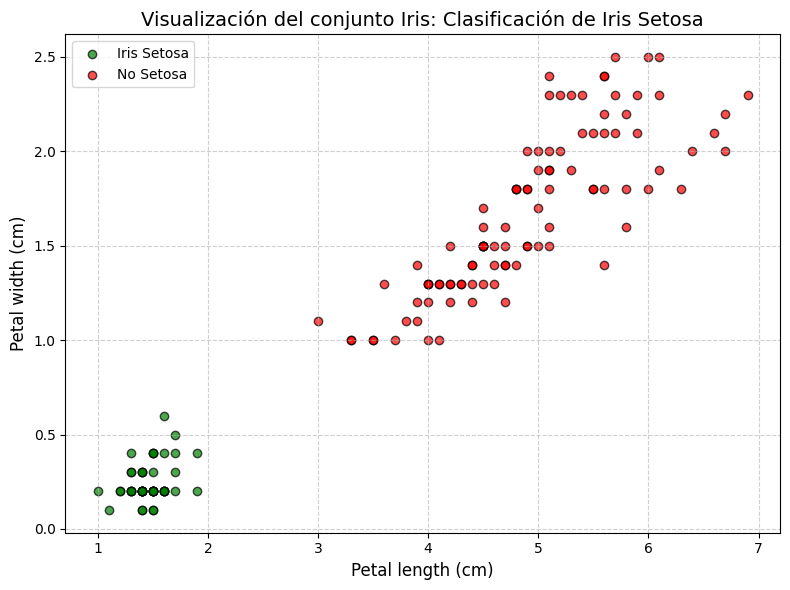

In [ ]:
# ============================================================
# Visualización de datos del conjunto Iris con Matplotlib
# ============================================================

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris(as_frame=True)

# Seleccionar las características de interés
X = iris.data[["petal length (cm)", "petal width (cm)"]].values

# Variable objetivo: 1 si es Iris Setosa, 0 en caso contrario
y = (iris.target == 0)

# Crear la figura
plt.figure(figsize=(8, 6))

# Graficar los puntos
plt.scatter(
    X[y, 0], X[y, 1],
    color="green", label="Iris Setosa", alpha=0.7, edgecolor="k"
) # Gráfica de la clase positiva 
plt.scatter(
    X[~y, 0], X[~y, 1],
    color="red", label="No Setosa", alpha=0.7, edgecolor="k"
) # Gráfica de la clase negativa

# Etiquetas y título
plt.xlabel("Petal length (cm)", fontsize=12)
plt.ylabel("Petal width (cm)", fontsize=12)
plt.title("Visualización del conjunto Iris: Clasificación de Iris Setosa", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


In [13]:
%%time 
# Entrenamiento del perceptrón
per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)


CPU times: total: 0 ns
Wall time: 998 μs


,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


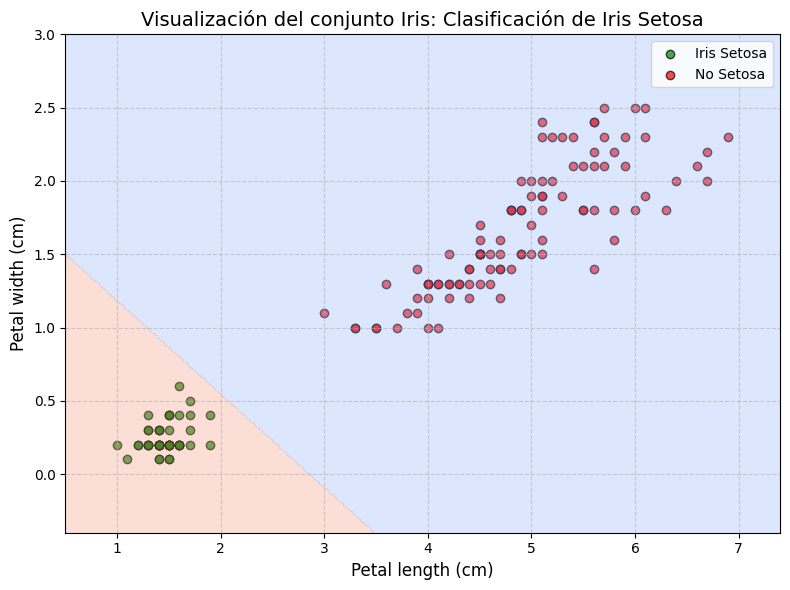

In [17]:
# ============================================================
# Visualización de datos del conjunto Iris con Matplotlib
# ============================================================

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris(as_frame=True)

# Seleccionar las características de interés
X = iris.data[["petal length (cm)", "petal width (cm)"]].values

# Variable objetivo: 1 si es Iris Setosa, 0 en caso contrario
y = (iris.target == 0)

# Crear la figura
plt.figure(figsize=(8, 6))

# Graficar los puntos
plt.scatter(
    X[y, 0], X[y, 1],
    color="green", label="Iris Setosa", alpha=0.7, edgecolor="k"
)
plt.scatter(
    X[~y, 0], X[~y, 1],
    color="red", label="No Setosa", alpha=0.7, edgecolor="k"
)

# Etiquetas y título
plt.xlabel("Petal length (cm)", fontsize=12)
plt.ylabel("Petal width (cm)", fontsize=12)
plt.title("Visualización del conjunto Iris: Clasificación de Iris Setosa", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# ------------------------------------------------------------
# 3. Crear una malla para graficar la frontera de decisión
# ------------------------------------------------------------
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predicción en toda la malla
Z = per_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ------------------------------------------------------------
# 4. Visualización
# Fondo coloreado según la predicción del modelo
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

In [18]:

# Predicción en dos nuevos ejemplos
X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)
y_pred  # [True, False]



array([ True, False])

## Nota
`Perceptron` en Scikit-Learn es equivalente a `SGDClassifier` con:
`loss="perceptron"`, `learning_rate="constant"`, `eta0=1`, `penalty=None`.





## 5. Limitaciones del Perceptrón

* No puede resolver problemas **no lineales**, como el famoso **XOR**.
* Esto desmotivó la investigación en los 70s (crisis de las redes neuronales).



Ejemplo: XOR no es linealmente separable → el perceptrón simple falla.

---



## 6. Solución: Multilayer Perceptron (MLP)

* Se crea una **red de perceptrones en capas**:

  * **Capa de entrada**
  * **Capas ocultas** (una o más)
  * **Capa de salida**

* Con al menos **una capa oculta**, se puede resolver XOR.

Ejemplo:

* Entradas $(0,0)$ y $(1,1)$ → salida $0$.
* Entradas $(0,1)$ y $(1,0)$ → salida $1$.

Así, un **MLP sí resuelve XOR**.

---


In [16]:
import numpy as np
from sklearn.neural_network import MLPClassifier

# Datos del problema XOR
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([0, 1, 1, 0])  # Etiquetas

# Definir un MLP con más neuronas en la capa oculta
mlp = MLPClassifier(hidden_layer_sizes=(4,),   # más neuronas que 2
                    activation='tanh',         # activación no lineal
                    solver='adam',             # adam suele converger mejor
                    learning_rate_init=0.1,    # tasa de aprendizaje más alta
                    max_iter=5000,             # más iteraciones
                    random_state=42)

# Entrenar
mlp.fit(X, y)

# Predicciones
print("Predicciones XOR:")
for i, x in enumerate(X):
    pred = mlp.predict([x])[0]
    prob = mlp.predict_proba([x])[0][1]
    print(f"{x} -> {pred} (probabilidad clase 1: {prob:.4f})")


Predicciones XOR:
[0 0] -> 0 (probabilidad clase 1: 0.0021)
[0 1] -> 1 (probabilidad clase 1: 0.9956)
[1 0] -> 1 (probabilidad clase 1: 0.9942)
[1 1] -> 0 (probabilidad clase 1: 0.0046)


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [3]:

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Datos del problema XOR
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0], [1], [1], [0]])


In [4]:

# Definir modelo secuencial
model = keras.Sequential([
    layers.Dense(4, input_dim=2, activation='tanh'),  # más neuronas ocultas
    layers.Dense(1, activation='sigmoid')             # salida binaria
])


c:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\1_administracion\ascolfa_2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:

# Compilar modelo (SGD suele aprender mejor en XOR)
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [6]:
%%time 
# Entrenar modelo
model.fit(X, y, epochs=5000, verbose=0)


In [7]:

# Evaluación
print("\nPredicciones XOR:")
preds = model.predict(X)
for i, p in enumerate(preds):
    print(f"{X[i]} -> {round(p[0])} (salida real: {p[0]:.4f})")

# Se demora más de 4 minutos en entrenar 


Predicciones XOR:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[0 0] -> 0 (salida real: 0.0009)
[0 1] -> 1 (salida real: 0.9945)
[1 0] -> 1 (salida real: 0.9935)
[1 1] -> 0 (salida real: 0.0073)



## 7. Retropropagación (Backpropagation)

Problema: ¿cómo entrenar un MLP?

### Solución:

En 1970, **Seppo Linnainmaa** propuso la **diferenciación automática en modo reverso (autodiff)**.
En los 80s, **Rumelhart, Hinton y Williams** la aplicaron a redes neuronales → **retropropagación**.



### Algoritmo:

1. **Forward pass**: calcular las salidas.
2. **Calcular error** (con función de pérdida).
3. **Backward pass**: aplicar la **regla de la cadena** para calcular gradientes.
4. **Actualizar pesos** con descenso de gradiente.

**Importante**: los pesos deben inicializarse **aleatoriamente** para evitar simetría.

---



## 8. Funciones de activación modernas

La función escalón se reemplazó por funciones **diferenciables**:

1. **Sigmoide**:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$



2. **Tangente hiperbólica**:

$$
\tanh(z) = 2\sigma(2z) - 1
$$



3. **ReLU (Rectified Linear Unit)**:

$$
\text{ReLU}(z) = \max(0, z)
$$

La **ReLU** es la más usada hoy: rápida, simple y efectiva.

---



## 9. Por qué se necesitan funciones de activación

* Si encadenas solo transformaciones **lineales**, el resultado siempre será **lineal**.
* Para capturar **relaciones no lineales**, necesitas **no linealidad entre capas**.
* Los MLP con activaciones no lineales pueden aproximar **cualquier función continua** (Teorema de aproximación universal).

---



# Conclusión

* El perceptrón fue la primera red neuronal artificial, pero limitado a problemas lineales.
* El MLP, entrenado con **retropropagación**, superó esa limitación.
* Hoy en día, MLPs con funciones como **ReLU** forman la base de las **redes profundas (DNNs)**.




# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Cálculo Vectorial para Ingeniería Agropecuaria
2. Análisis Numérico para Licenciatura en Matemáticas. 
3. Práctica Pedagógica V para Licenciatura en Educación Infantil
4. Fundamentos de Lógica para Licenciatura en Matemáticas 


# Horario de clases del profesor Marco

* Lunes 8-12: Cálculo Vectorial
* Martes 8-12 M: Análisis Numérico. 
* Miércoles 10 a 11 M: Machine Learnig
* Miércoles de 3 a 4 de la tarde: ARIMA
* Jueves 2 a 6 PM: Práctica Pedagógica V: Desarrollo del pensamiento matemático en   
  la infancia. 
* Viernes 8 - 12 M: Fundamentos de Lógica. 
* Sábados 8-12 Asesorías y espacio para retroalimentación y apoyo al trabajo independiente  
  y desarrollo de habilidades metacognitivas. 

# Coordinador de los cursos de la Facultad de Educación para regiones:    

Andrés Vélez: regioneducacion.fedu@udea.edu.co  
Coordinador Regiones  
Facultad de Educación  
Universidad de Antioquia  

## Monitores
* Manuel San Juan Serrano: Contactar escribiendo al correo: manuel.serrano1@udea.edu.co
* Yeifry Sebastián Uribe: Contactar escribiendo al correo: yeifry.uribe@udea.edu.co

## Referentes 

* [Jupyter Book de fundamentos_logica](file:///C:/Users/marco/Documentos/docencia/fundamentos_logica/fundamentos_logica_book/_build/html/index.html)


* [Decargue Crocodile Clip aquí](https://crocodileclips.net/descargar-crocodile-clips/)

* [Matemáticas discretas Una introducción abierta, 3ª edición](https://discrete.openmathbooks.org/dmoi3.html)  
  
* [Desarrollo del pensamiento matemático con calculadora Casio ](https://bibliotecadigital.udea.edu.co/entities/publication/17180405-9f1d-4800-aa7c-e6369779cece)

* [CALCULO I DE UNA VARIABLE Ron Larson-Bruce Edwards. Mc Graw Hill. 9º Edición](https://www.academia.edu/42139251/CALCULO_I_DE_UNA_VARIABLE_Ron_Larson_Bruce_Edwards_Mc_Graw_Hill_9o_Edici%C3%B3n)   
  

* [Grajales Vanegas, L. M., Restrepo Estrada, C. E., Restrepo Ochoa, S. I., & Ruíz De Villalba, F. (2015). Matemáticas I para las ciencias económicas.](https://bibliotecadigital.udea.edu.co/handle/10495/3010)
  
* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html

* [Aylwin, C. U. (2011). Lógica, conjuntos y números. Universidad de los Andes, Consejo de Publicaciones, Colección: Ciencias Básicas, Serie: Matemáticas.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.u-cursos.cl/ciencias/2011/1/MC110/1/material_docente/bajar?id_material=574722)
  
* [Chollet, F. (2021). Deep learning with Python. Simon and Schuster.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://tanthiamhuat.wordpress.com/wp-content/uploads/2018/03/deeplearningwithpython.pdf)  
  
* [Watson, S., Stewart, J., & Redlin, L. (2009). Precálculo. Matemáticas para el cálculo.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://students.aiu.edu/submissions/profiles/resources/onlineBook/k6L8A3_precalculo_-_matematicas_para_el_calculo-1.pdf)  

* [Purcell, E. J., Varberg, D., & Rigdon, S. E. (2007). Cálculo diferencial e integral. Pearson Educación.](https://github.com/marco-canas/calculo/blob/main/referents/purcell/purcell_calculo.pdf)

  

* [stewart cálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EZgXZjAp8QxPqOAim2hs6LcBNPLGjSHf-xwYnUVYkwa04w?e=RZdTCy)  


* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)

* [chatGPT](https://openai.com/blog/chatgpt)  

* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 

# Como estudiante, encuentro que...   

F: Mis Fortalezas son:     
O: Mis Oportunidades son:    
D: Mis Debilidades son:    
A: Lo que Amenazas mi aprendizaje es:  

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado. Este hijo me enorgullece y me hace falta abrazarlo cada día. 

Y a mi esposa Yasmira Emperatriz Barboza Mogollón por su apoyo, orientación y acompañamiento. 